In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
import json
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Setup Kaggle
os.makedirs('/root/.kaggle', exist_ok=True)
kaggle_json = {
    "username": "itxminoo",
    "key": "KGAT_4c9b6753aeb313fd7be04409838e5992"
}
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_json, f)
os.chmod('/root/.kaggle/kaggle.json', 600)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")
print("Kaggle configured ✅")

TensorFlow version: 2.20.0
GPU available: []
Kaggle configured ✅


In [2]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
print("Downloaded ✅")

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [03:52<00:00, 24.0MB/s]

Downloaded ✅


In [3]:
import zipfile

print("Extracting... ⏳ This may take 2-3 minutes")
with zipfile.ZipFile('skin-cancer-mnist-ham10000.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/skin_dataset')
print("Extracted ✅")

# Check structure
for root, dirs, files in os.walk('/content/skin_dataset'):
    level = root.replace('/content/skin_dataset', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if files and level < 2:
        print(f'{indent}  ({len(files)} files)')

Extracting... ⏳ This may take 2-3 minutes
Extracted ✅
skin_dataset/
  (5 files)
  ham10000_images_part_1/
    (5000 files)
  HAM10000_images_part_2/
    (5015 files)
  HAM10000_images_part_1/
    (5000 files)
  ham10000_images_part_2/
    (5015 files)


In [4]:
import pandas as pd

# Find the CSV metadata file
for file in os.listdir('/content/skin_dataset'):
    if file.endswith('.csv'):
        print(f"Found: {file}")

# Load metadata
metadata = pd.read_csv('/content/skin_dataset/HAM10000_metadata.csv')
print(f"\nMetadata shape: {metadata.shape}")
print(f"\nColumns: {metadata.columns.tolist()}")
print(f"\nDiagnosis types:")
print(metadata['dx'].value_counts())
metadata.head()


Found: hmnist_28_28_RGB.csv
Found: hmnist_28_28_L.csv
Found: hmnist_8_8_L.csv
Found: HAM10000_metadata.csv
Found: hmnist_8_8_RGB.csv

Metadata shape: (10015, 7)

Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

Diagnosis types:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [5]:
# Map diagnosis to binary: 0=Benign, 1=Malignant
malignant_types = ['mel', 'bcc', 'akiec']
metadata['binary_label'] = metadata['dx'].apply(
    lambda x: 1 if x in malignant_types else 0)

print("Binary distribution:")
print(metadata['binary_label'].value_counts())

# Create full image paths
def get_image_path(image_id):
    path1 = f'/content/skin_dataset/HAM10000_images_part_1/{image_id}.jpg'
    path2 = f'/content/skin_dataset/HAM10000_images_part_2/{image_id}.jpg'
    if os.path.exists(path1):
        return path1
    elif os.path.exists(path2):
        return path2
    return None

metadata['image_path'] = metadata['image_id'].apply(get_image_path)
print(f"\nImages found: {metadata['image_path'].notna().sum()}/{len(metadata)}")

Binary distribution:
binary_label
0    8061
1    1954
Name: count, dtype: int64

Images found: 10015/10015


In [6]:
import cv2
import numpy as np

IMG_SIZE = 100
SAMPLES_PER_CLASS = 800  # Balanced sampling

# Get balanced samples
benign_samples = metadata[metadata['binary_label']==0].sample(
    n=SAMPLES_PER_CLASS, random_state=42)
malignant_samples = metadata[metadata['binary_label']==1].sample(
    n=min(SAMPLES_PER_CLASS, 1954), random_state=42)

balanced_df = pd.concat([benign_samples, malignant_samples])
print(f"Balanced dataset: {len(balanced_df)} images")
print(balanced_df['binary_label'].value_counts())

# Load images
images = []
labels = []

for idx, row in balanced_df.iterrows():
    img = cv2.imread(row['image_path'])
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        images.append(img)
        labels.append(row['binary_label'])

X = np.array(images, dtype=np.float32) / 255.0
y = np.array(labels)

print(f"\nFinal shape: {X.shape}")
print(f"Benign: {(y==0).sum()}, Malignant: {(y==1).sum()}")

Balanced dataset: 1600 images
binary_label
0    800
1    800
Name: count, dtype: int64

Final shape: (1600, 100, 100, 3)
Benign: 800, Malignant: 800


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Train - Benign: {(y_train==0).sum()}, Malignant: {(y_train==1).sum()}")
print(f"Test - Benign: {(y_test==0).sum()}, Malignant: {(y_test==1).sum()}")

Train: 1280 | Test: 320
Train - Benign: 640, Malignant: 640
Test - Benign: 160, Malignant: 160


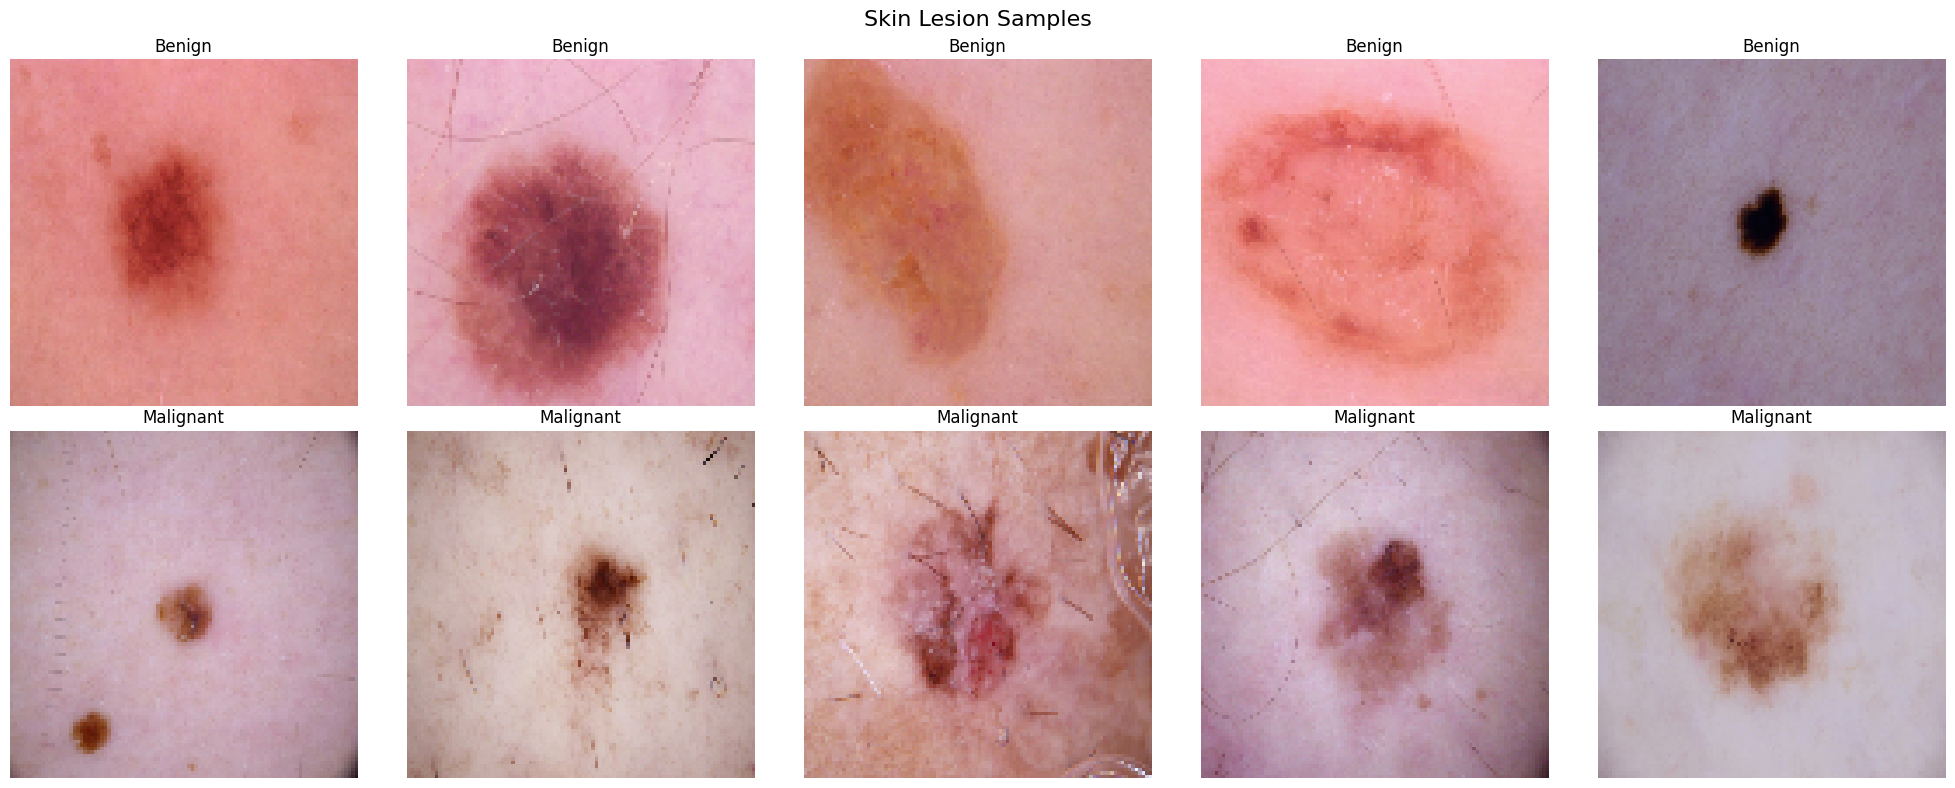

Saved! ✅


In [8]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

benign_idx = np.where(y_train==0)[0][:5]
malignant_idx = np.where(y_train==1)[0][:5]

for i, idx in enumerate(benign_idx):
    axes[0, i].imshow(X_train[idx])
    axes[0, i].set_title('Benign')
    axes[0, i].axis('off')

for i, idx in enumerate(malignant_idx):
    axes[1, i].imshow(X_train[idx])
    axes[1, i].set_title('Malignant')
    axes[1, i].axis('off')

plt.suptitle('Skin Lesion Samples', fontsize=16)
plt.tight_layout()
plt.savefig('skin_cancer_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved! ✅")

In [9]:
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

tf.keras.backend.clear_session()

def build_skin_cnn(input_shape=(100, 100, 3)):
    model = tf.keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu',
                     input_shape=input_shape, padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model = build_skin_cnn()
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()
print("CNN built ✅")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

CNN built ✅


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15
)
datagen.fit(X_train)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=8, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.5, patience=4, verbose=1, min_lr=1e-6)
]

print("Training started... ⏳")
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=25,
    callbacks=callbacks
)
print("Training complete! ✅")

Training started... ⏳
Epoch 1/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 477ms/step - accuracy: 0.5367 - loss: 0.6867 - val_accuracy: 0.4938 - val_loss: 0.6546 - learning_rate: 0.0010
Epoch 2/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 460ms/step - accuracy: 0.6562 - loss: 0.6105 - val_accuracy: 0.6938 - val_loss: 0.5488 - learning_rate: 0.0010
Epoch 3/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 468ms/step - accuracy: 0.6727 - loss: 0.6010 - val_accuracy: 0.6906 - val_loss: 0.5870 - learning_rate: 0.0010
Epoch 4/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 480ms/step - accuracy: 0.6781 - loss: 0.5913 - val_accuracy: 0.7281 - val_loss: 0.5283 - learning_rate: 0.0010
Epoch 5/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 485ms/step - accuracy: 0.6766 - loss: 0.5878 - val_accuracy: 0.7437 - val_loss: 0.5146 - learning_rate: 0.0010
Epoch 6/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 471ms/step - accuracy: 0.6875 - loss: 0.5731 - val_accuracy: 0.7375 - val_loss: 0.5468 - learning_rate: 0.0010
Epoch 7/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 464ms/step - accur

In [11]:
results = model.evaluate(X_test, y_test, verbose=1)
print("\n" + "="*40)
print("🎯 FINAL MODEL RESULTS")
print("="*40)
print(f"Test Loss:     {results[0]:.4f}")
print(f"Test Accuracy: {results[1]*100:.2f}%")
print("="*40)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 240ms/step - accuracy: 0.7750 - loss: 0.4550

🎯 FINAL MODEL RESULTS
Test Loss:     0.4550
Test Accuracy: 77.50%


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step
              precision    recall  f1-score   support

      Benign       0.91      0.61      0.73       160
   Malignant       0.71      0.94      0.81       160

    accuracy                           0.78       320
   macro avg       0.81      0.78      0.77       320
weighted avg       0.81      0.78      0.77       320



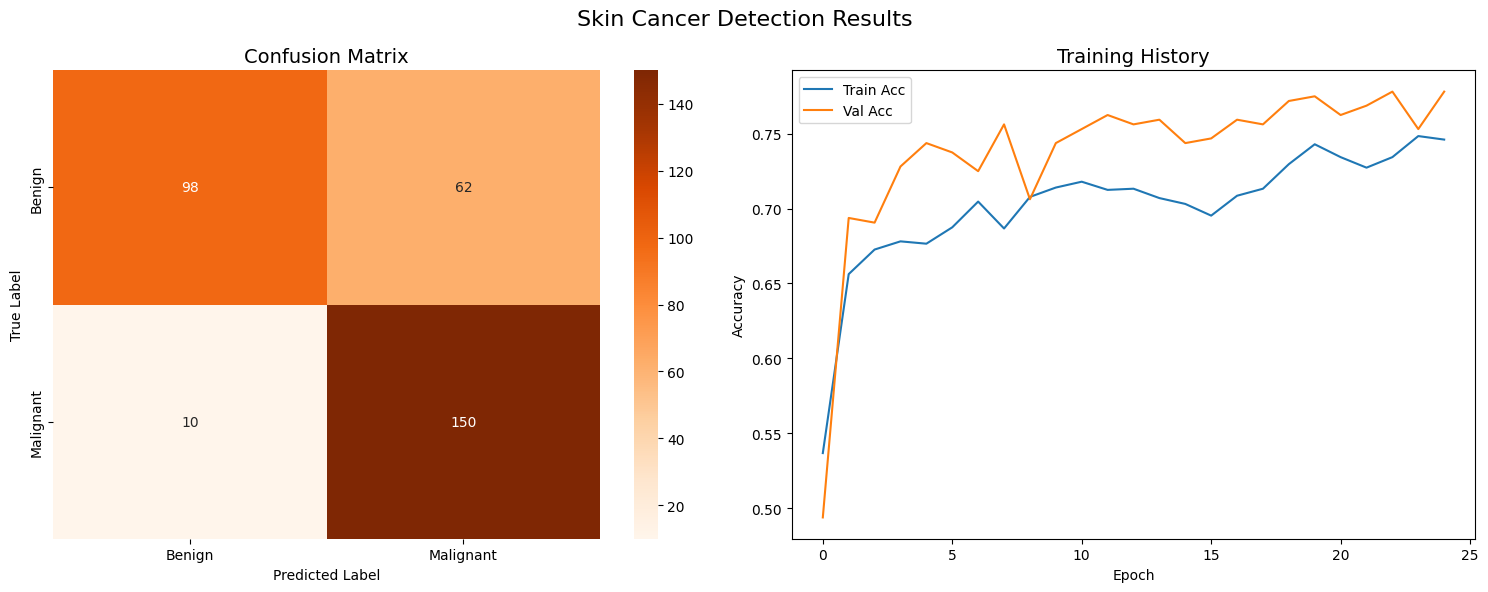

Results saved! ✅


In [12]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred,
    target_names=['Benign', 'Malignant']))

cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(cm, annot=True, fmt='d', ax=axes[0],
    cmap='Oranges',
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant'])
axes[0].set_title('Confusion Matrix', fontsize=14)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

axes[1].plot(history.history['accuracy'], label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Training History', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Skin Cancer Detection Results', fontsize=16)
plt.tight_layout()
plt.savefig('skin_cancer_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Results saved! ✅")

In [13]:
model.save('skin_cancer_model.h5')
print("✅ Model saved")

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('skin_cancer_model.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"✅ TFLite size: {len(tflite_model)/1024/1024:.2f} MB")

✅ Model saved
Saved artifact at '/tmp/tmp5hg6p2qz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135412717089040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135412717089808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135412717091920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135412717090576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135412717091344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135412717092496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135412717089424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135412717092304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135412717091728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135412447429456: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ 

In [14]:
from google.colab import files

files.download('skin_cancer_samples.png')
files.download('skin_cancer_results.png')
files.download('skin_cancer_model.tflite')
print("All downloaded! ✅")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All downloaded! ✅
